In [1]:
import torch
print(torch.__version__)

2.10.0


In [2]:
import os
from PIL import Image
from collections import Counter
import torch
from torch.utils.data import Dataset
from PIL import Image
import os
import torch
import torchvision.models.video as video_models
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np




In [3]:
root_dir = 'frames 100'  
sizes = []

for subdir, dirs, files in os.walk(root_dir):
    for file in files:
        if file.endswith(('.jpg', '.png', '.jpeg')):
            file_path = os.path.join(subdir, file)
            with Image.open(file_path) as img:
                sizes.append(img.size) # returns (width, height)

# Summarize the findings
size_counts = Counter(sizes)
print("--- Data Size Audit ---")
for size, count in size_counts.items():
    print(f"Size {size}: found in {count} images")

--- Data Size Audit ---
Size (1280, 1024): found in 12256 images


In [4]:
class DriveActTransformerDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        # I am updating the class names based on your folders. 
        # Make sure these match your folder names EXACTLY!
        self.classes = ['eat_drink 100', 'fasten_seat_belt 100', 'put_on_jacket', 'put_on_sunglasses', 'read_magazine']
        self.clips = []

        for label, class_name in enumerate(self.classes):
            class_path = os.path.join(root_dir, class_name)
            
            # I am checking if the path exists to avoid errors
            if not os.path.exists(class_path):
                print(f"Warning: Path {class_path} not found. Skipping...")
                continue
                
            for clip_folder in os.listdir(class_path):
                full_clip_path = os.path.join(class_path, clip_folder)
                
                # FIX 1: I only add it if it is actually a DIRECTORY
                if os.path.isdir(full_clip_path):
                    self.clips.append((full_clip_path, label))

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, idx):
        clip_path, label = self.clips[idx]
        
        # FIX 2: I only grab files that look like images (jpg, png, etc.)
        frame_files = sorted([
            f for f in os.listdir(clip_path) 
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])
        
        frames = []
        for f in frame_files:
            img = Image.open(os.path.join(clip_path, f)).convert('RGB')
            if self.transform:
                img = self.transform(img)
            frames.append(img)

        # I am making sure we actually found frames before stacking
        if len(frames) == 0:
            raise RuntimeError(f"No frames found in {clip_path}")

        video_tensor = torch.stack(frames).permute(1, 0, 2, 3)
        return video_tensor, label

In [5]:


def get_video_swin_model(num_classes=5):
    # I am loading the 'Swin Transformer 3D Tiny' model.
    # I set weights='DEFAULT' to automatically get the best pre-trained 
    # version (usually trained on Kinetics-400).
    model = video_models.swin3d_t(weights='DEFAULT')
    
    # I need to find the final classification layer.
    # In this model, it's located at 'model.head'.
    # I'll check the number of input features (how many "thoughts" the model 
    # has before making a decision).
    in_features = model.head.in_features
    
    # Now I swap the old 400-class head for your 5-class head.
    # I am literally throwing away the old output layer and 
    # soldering on a new one.
    model.head = torch.nn.Linear(in_features, num_classes)
    
    return model

# Let's try initializing it again!
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
my_model = get_video_swin_model(num_classes=5).to(device)

print(f"Success! Model is loaded on {device} and ready for your 5 classes.")

Success! Model is loaded on cpu and ready for your 5 classes.


In [6]:
def train_and_validate(model, train_loader, val_loader, epochs=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.05) # Increased weight decay to fight overfitting!
    
    # I'm creating a dictionary to store the history of the run
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_loss = 0.0
        for videos, labels in train_loader:
            videos, labels = videos.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(videos)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        # --- VALIDATION PHASE ---
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for videos, labels in val_loader:
                videos, labels = videos.to(device), labels.to(device)
                outputs = model(videos)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        # I'm calculating the averages for this specific epoch
        avg_train = train_loss / len(train_loader)
        avg_val = val_loss / len(val_loader)
        accuracy = 100. * correct / total

        # I'm recording these values into our history dictionary
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        history['val_acc'].append(accuracy)

        print(f'Epoch {epoch+1}: Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | Acc: {accuracy:.2f}%')

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), 'best_video_swin.pth')
            print("--> New Best Model Saved!")
            
    # CRITICAL: I am returning the history so you can plot it in the next cell
    return history

In [11]:


# defining the "Prep" steps for the images
# resizing them to 224x224 because that's what Video Swin expects
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# pointing to my root directory
full_dataset = DriveActTransformerDataset(root_dir='frames 100', transform=transform)

#splitting the data (80% for training, 20% for testing)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_set, val_set = random_split(full_dataset, [train_size, val_size])

# creating the "Loaders" which serve the videos to the model in chunks (batches)
# using a batch size of 4. Video models use a lot of memory, so start small
train_loader = DataLoader(train_set, batch_size=4, shuffle=True)
val_loader = DataLoader(val_set, batch_size=4, shuffle=False)

#  I am finally starting the training
print("Starting the engine...")
train_history = train_and_validate(my_model, train_loader, val_loader, epochs=5)


Starting the engine...
Epoch 1: Train Loss: 0.1192 | Val Loss: 0.0382 | Acc: 98.70%
--> New Best Model Saved!
Epoch 2: Train Loss: 0.0636 | Val Loss: 0.0297 | Acc: 99.35%
--> New Best Model Saved!
Epoch 3: Train Loss: 0.0460 | Val Loss: 0.0323 | Acc: 100.00%
Epoch 4: Train Loss: 0.0265 | Val Loss: 0.0277 | Acc: 98.70%
--> New Best Model Saved!
Epoch 5: Train Loss: 0.0308 | Val Loss: 0.0558 | Acc: 98.05%


--- Classification Report ---
              precision    recall  f1-score   support

         eat       1.00      1.00      1.00        26
    seatbelt       0.96      1.00      0.98        27
      jacket       0.97      1.00      0.98        31
  sunglasses       1.00      0.97      0.98        33
    magazine       1.00      0.97      0.99        37

    accuracy                           0.99       154
   macro avg       0.99      0.99      0.99       154
weighted avg       0.99      0.99      0.99       154



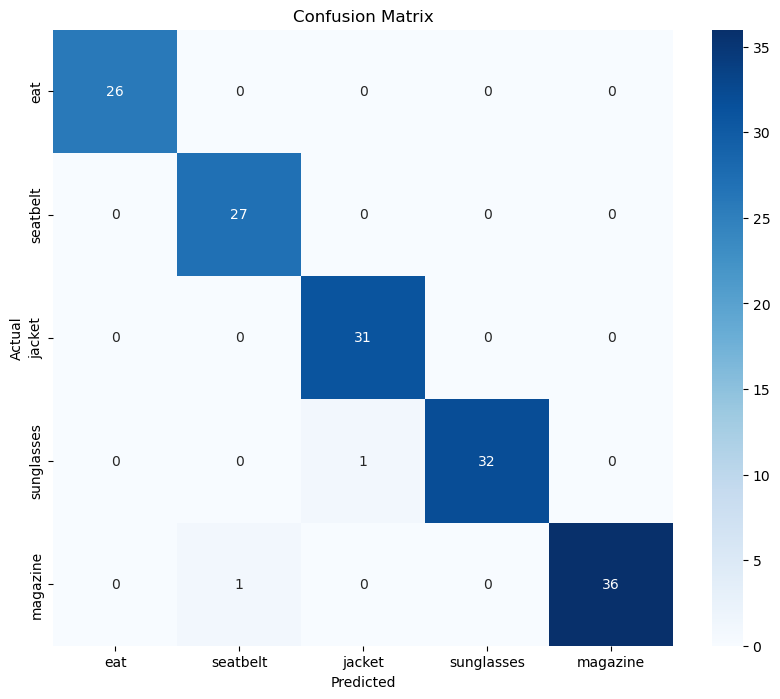

In [12]:
def get_final_metrics(model, val_loader, device):
    # I load the best weights we saved earlier
    model.load_state_dict(torch.load('best_video_swin.pth'))
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for videos, labels in val_loader:
            videos, labels = videos.to(device), labels.to(device)
            outputs = model(videos)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 1. The Accuracy Report
    print("--- Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=['eat', 'seatbelt', 'jacket', 'sunglasses', 'magazine']))

    # 2. The Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['eat', 'seatbelt', 'jacket', 'sunglasses', 'magazine'],
                yticklabels=['eat', 'seatbelt', 'jacket', 'sunglasses', 'magazine'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

# I call the function
get_final_metrics(my_model, val_loader, device)

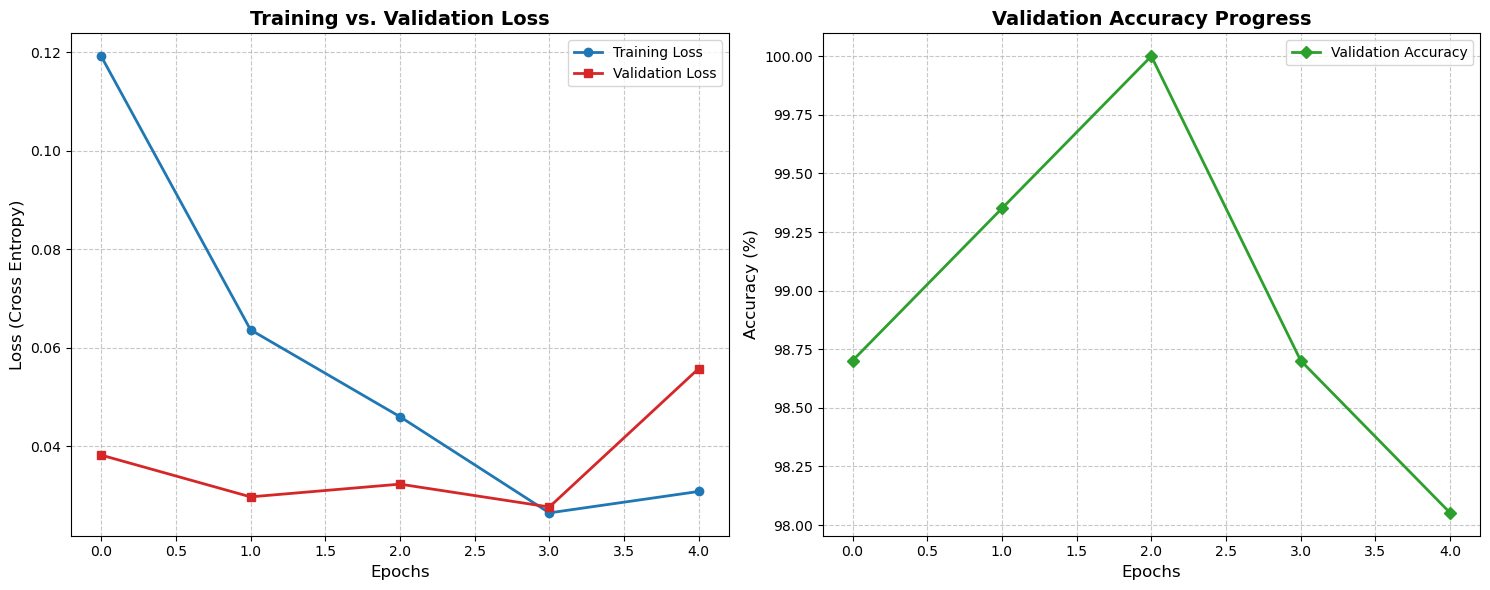

In [13]:


# I am setting a clean style for the plots
plt.style.use('seaborn-v0_8-muted') 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: Loss (The most important for spotting overfitting) ---
ax1.plot(train_history['train_loss'], 'o-', label='Training Loss', color='#1f77b4', linewidth=2)
ax1.plot(train_history['val_loss'], 's-', label='Validation Loss', color='#d62728', linewidth=2)
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss (Cross Entropy)', fontsize=12)
ax1.set_title('Training vs. Validation Loss', fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# --- Plot 2: Accuracy ---
ax2.plot(train_history['val_acc'], 'D-', label='Validation Accuracy', color='#2ca02c', linewidth=2)
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Validation Accuracy Progress', fontsize=14, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

In [14]:
# I am saving a final, timestamped version 
torch.save(my_model.state_dict(), 'drive_and_act_swin_v1.pth')
print("Model weights saved successfully as drive_and_act_swin_v1.pth")

Model weights saved successfully as drive_and_act_swin_v1.pth


In [6]:
import cv2
import torch
from PIL import Image
from torchvision import transforms

def predict_video(video_path, model, device):
    # I corrected 'transform.Compose' to 'transforms.Compose'
    transform_pipeline = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    cap = cv2.VideoCapture(video_path)
    frames = []

    # Check if video actually opened
    if not cap.isOpened():
        return "Error: Could not open video file", 0.0

    while len(frames) < 16:
        ret, frame = cap.read()
        if not ret:
            break
        
        # --- CRITICAL FIX ---
        # Your previous code had the following lines indented UNDER the 'break'.
        # That meant they only ran if the video FAILED, which is impossible.
        # I moved them out so they run for every successful frame read.
        
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) # Fixed typo 'cvrColor' and 'frae'
        pil_img = Image.fromarray(frame)
        frames.append(transform_pipeline(pil_img))

    cap.release()

    if len(frames) < 16:
        return f"Error: Video too short (only found {len(frames)} frames)", 0.0

    # Stacking and shaping: [1, 3, 16, 224, 224]
    input_tensor = torch.stack(frames).permute(1, 0, 2, 3).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.nn.functional.softmax(output, dim=1)
        prediction_idx = torch.argmax(probabilities, dim=1).item()
        confidence = probabilities[0][prediction_idx].item()

    classes = ['eat', 'seatbelt', 'jacket', 'sunglasses', 'magazine']
    return classes[prediction_idx], confidence

# --- EXECUTION ---
# Ensure weights are loaded BEFORE calling the function
my_model.load_state_dict(torch.load('best_video_swin.pth', map_location=device))

video_to_test = '/Users/dell/Library/Mobile Documents/com~apple~CloudDocs/DMS/videos/vp8/run2_2018-05-23-15-30-27.ids_1.mp4'
action, score = predict_video(video_to_test, my_model, device)

print(f'Predicted Action: {action} ({score*100:.2f}% confidence)')

NameError: name 'my_model' is not defined

In [3]:
import cv2
import torch
from PIL import Image
from torchvision import transforms

def analyze_and_report(video_path, model, device):
    # 1. Define the same prep-steps we used for training
    transform_pipeline = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # We will store one prediction for every "window" of time
    timeline = []
    classes = ['eat', 'seatbelt', 'jacket', 'sunglasses', 'magazine']
    
    print(f"Analyzing video: {video_path}")
    print(f"Total video duration: {total_frames/fps:.2f} seconds")

    while cap.isOpened():
        frames = []
        # Grab a 16-frame window
        for _ in range(16):
            ret, frame = cap.read()
            if not ret: break
            
            # Prep each frame
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(frame_rgb)
            frames.append(transform_pipeline(pil_img))
        
        if len(frames) < 16: break
        
        # 2. Predict the action for this specific window
        input_tensor = torch.stack(frames).permute(1, 0, 2, 3).unsqueeze(0).to(device)
        model.eval()
        with torch.no_grad():
            output = model(input_tensor)
            pred_idx = torch.argmax(output, dim=1).item()
            timeline.append(pred_idx)
        
        # 3. SPEED OPTIMIZATION: 
        # Instead of every single frame, we jump ahead 1 second to find the next action.
        # This makes the analysis much faster for long videos.
        current_pos = cap.get(cv2.CAP_PROP_POS_FRAMES)
        cap.set(cv2.CAP_PROP_POS_FRAMES, current_pos + int(fps))

    cap.release()

    # 4. Data Analysis: Calculate Durations
    report = {cls: 0 for cls in classes}
    for entry in timeline:
        report[classes[entry]] += 1 # Each entry represents roughly 1 second

    print("\n--- Final Activity Report ---")
    for activity, seconds in report.items():
        mins, secs = divmod(seconds, 60)
        print(f"{activity.capitalize():<12}: {mins}m {secs}s")
    
    return timeline

In [5]:
# Make sure your model has the best weights loaded first!
my_model.load_state_dict(torch.load('best_video_swin.pth', map_location=device))

# Path to your long video
long_video_path = "/Users/dell/Downloads/Download.mov"

# Run the analysis
activity_history = analyze_and_report(long_video_path, my_model, device)

NameError: name 'my_model' is not defined

In [ ]:
def train_and_validate(model, train_loader, val_loader, epochs=50):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    # I'm using CrossEntropy for our 5 classes
    criterion = nn.CrossEntropyLoss()
    
    # I'm using a very small learning rate. Since I'm using pre-trained weights,
    # I don't want to "scare" the model with huge updates that destroy its knowledge.
    optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)
    
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_loss = 0.0
        for videos, labels in train_loader:
            videos, labels = videos.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(videos)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        # --- VALIDATION PHASE
        model.eval() # I turn off Dropout and BatchNormalization
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad(): # No gradients needed, saves memory
            for videos, labels in val_loader:
                videos, labels = videos.to(device), labels.to(device)
                outputs = model(videos)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                # I also want to track accuracy to see if it's actually learning
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        avg_train = train_loss / len(train_loader)
        avg_val = val_loss / len(val_loader)
        accuracy = 100. * correct / total

        print(f'Epoch {epoch+1}: Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | Acc: {accuracy:.2f}%')

        # EARLY STOPPING CHECK
        # If the validation loss improves, I save the "best" version of the model.
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), 'best_video_swin.pth')
            print("Validation improved! Saving model...")